# 0. Getting setup

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 37.80 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 1. Get Data

In [4]:
!pip install -q kagglehub

In [5]:
import kagglehub
from pathlib import Path

DATA_DIR = Path("/content/picksense/data/raw/openloris")
DATA_DIR.mkdir(parents=True, exist_ok=True)

path = kagglehub.dataset_download(
    "zhedamai/openlorisobject",
    output_dir=str(DATA_DIR)
)

print("Downloaded to:")
print(path)

100%|██████████| 18.2G/18.2G [03:16<00:00, 99.7MB/s]

Extracting files...


Downloaded to:
/content/picksense/data/raw/openloris


In [6]:
# Check if the dataset folder exists and list its contents
print("Dataset folder exists:", DATA_DIR.exists())

for item in DATA_DIR.iterdir():
    print(item.name)

Dataset folder exists: True
.complete
openloris


In [7]:
# List the first 100 files in the dataset directory
count = 0

for item in DATA_DIR.rglob("*"):
    print(item.relative_to(DATA_DIR))

    count += 1
    if count == 100:
        break

.complete
openloris
.complete/datasets
openloris/occlusion
openloris/clutter
openloris/pixel
openloris/sequence
openloris/illumination
.complete/datasets/zhedamai
.complete/datasets/zhedamai/openlorisobject
.complete/datasets/zhedamai/openlorisobject/2
.complete/datasets/zhedamai/openlorisobject/2/bundle.complete
openloris/occlusion/train
openloris/occlusion/test
openloris/clutter/train
openloris/clutter/test
openloris/pixel/train
openloris/pixel/test
openloris/sequence/train
openloris/sequence/test
openloris/sequence/validation
openloris/illumination/train
openloris/illumination/test
openloris/occlusion/train/task2
openloris/occlusion/train/task9
openloris/occlusion/train/task8
openloris/occlusion/train/note
openloris/occlusion/train/task5
openloris/occlusion/train/task3
openloris/occlusion/train/task7
openloris/occlusion/train/task4
openloris/occlusion/train/task6
openloris/occlusion/train/task1
openloris/occlusion/test/task2
openloris/occlusion/test/task9
openloris/occlusion/test/ta

In [8]:
from pathlib import Path

DATASET_DIR = Path(path)   # path returned by kagglehub

image_extensions = {".jpg", ".jpeg", ".png"}

images = [
    p for p in DATASET_DIR.rglob("*")
    if p.suffix.lower() in image_extensions
]

print("Number of image files found:", len(images))

print("\nFirst 10 images:")
for img_path in images[:10]:
    print(img_path)

Number of image files found: 404060

First 10 images:
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0192.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0146.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0145.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0148.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0016.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0233.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0186.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0030.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0230.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/

Image path: /content/picksense/data/raw/openloris/openloris/occlusion/train/task2/scissors_02/frame0192.jpg
Image size: (424, 240)


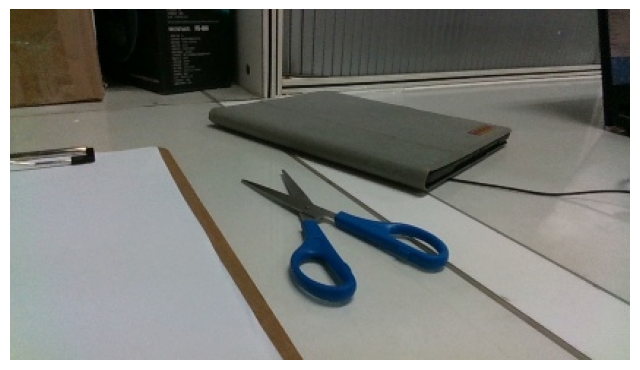

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = images[0]

img = Image.open(img_path)

print("Image path:", img_path)
print("Image size:", img.size)

plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
import os, shutil
from pathlib import Path

# --- locate OpenLORIS occlusion root (handles nested openloris/openloris) ---
BASE = Path("/content/picksense/data/raw/openloris")
OCC = [p for p in BASE.rglob("occlusion") if p.is_dir()][0]
print("occlusion source:", OCC)

# --- 9 difficulty-ordered tasks -> occlusion % -> pickability label ---
TASK_TO_LABEL = {
     "task1": "clear",
    "task2": "clear",
    "task3": "clear",              # 0% occlusion

    "task4": "partially_occluded",
    "task5": "partially_occluded",
    "task6": "partially_occluded", # 25% occlusion

    "task7": "heavily_occluded",
    "task8": "heavily_occluded",
    "task9": "heavily_occluded"    # 50% occlusion
}

CLASSES = ["clear", "partially_occluded", "heavily_occluded"]

image_path = Path("/content/picksense/data/pickability_occlusion")
USE_SYMLINKS = True  # fast, no extra disk

def build_split(split):
    made = {c: 0 for c in CLASSES}
    for task_dir in sorted(p for p in (OCC / split).iterdir() if p.is_dir()):
        label = TASK_TO_LABEL.get(task_dir.name)
        if label is None:
            continue
        out_dir = image_path / split / label
        out_dir.mkdir(parents=True, exist_ok=True)
        for inst_dir in sorted(p for p in task_dir.iterdir() if p.is_dir()):
            for img in inst_dir.glob("*.jpg"):
                link = out_dir / f"{task_dir.name}__{inst_dir.name}__{img.name}"
                if link.exists() or link.is_symlink():
                    continue
                if USE_SYMLINKS:
                    os.symlink(img.resolve(), link)
                else:
                    shutil.copy2(img, link)
                made[label] += 1
    return made

if image_path.exists():
    shutil.rmtree(image_path)   # fresh build so counts are exact

for split in ["train", "test"]:
    counts = build_split(split)
    print(f"[{split}] linked:", counts, "total:", sum(counts.values()))

# --- FoodVision-style paths ---
train_dir = image_path / "train"
test_dir  = image_path / "test"
print("\nimage_path:", image_path)
print("train_dir :", train_dir)
print("test_dir  :", test_dir)

occlusion source: /content/picksense/data/raw/openloris/openloris/occlusion
[train] linked: {'clear': 14008, 'partially_occluded': 14214, 'heavily_occluded': 14008} total: 42230
[test] linked: {'clear': 1632, 'partially_occluded': 1656, 'heavily_occluded': 1632} total: 4920

image_path: /content/picksense/data/pickability_occlusion
train_dir : /content/picksense/data/pickability_occlusion/train
test_dir  : /content/picksense/data/pickability_occlusion/test


In [11]:
from torchvision import datasets
train_data = datasets.ImageFolder(train_dir)
test_data  = datasets.ImageFolder(test_dir)
print("classes:", train_data.classes)
print("train:", len(train_data), "| test:", len(test_data))
print("per-class train:", {c: train_data.targets.count(i) for i, c in enumerate(train_data.classes)})
print("per-class test:", {c: test_data.targets.count(i) for i, c in enumerate(test_data.classes)})

classes: ['clear', 'heavily_occluded', 'partially_occluded']
train: 42230 | test: 4920
per-class train: {'clear': 14008, 'heavily_occluded': 14008, 'partially_occluded': 14214}
per-class test: {'clear': 1632, 'heavily_occluded': 1632, 'partially_occluded': 1656}


# 2. Create Datasets and DataLoaders

### 2.1 Prepare transforms for images


In [12]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

import torchvision.transforms as transforms
# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into DataLoader's
Transforms created!

Let's now create our DataLoader's.

The ViT paper states the use of a batch size of 4096 which is 128x the size of the batch size we've been using (32).

However, we're going to stick with a batch size of 32.

In [13]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

len(train_dataloader), len(test_dataloader), class_names

(1320, 154, ['clear', 'heavily_occluded', 'partially_occluded'])

### 2.3 Visualize a single image

In [27]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(0))

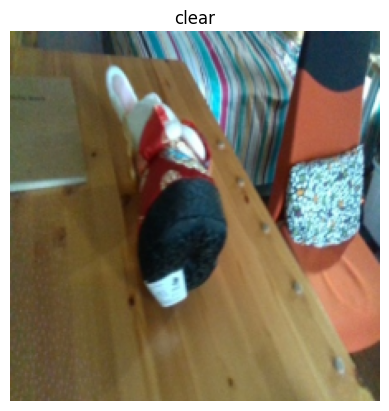

In [28]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

# 3. Replicating the ViT paper: an overview

Looking at a whole machine learning paper can be overwhelming, especially if it's a new architecture or model. To make it easier to understand, let's break down the ViT paper into its core components.

* **inputs** - What goes into the model (e.g. images, text, audio, etc.)
* **outputs** - What comes out the model/layer/block? (in this case, i want the model to output classification labels)
* **layers** - Takes an inputs, manipulates it with a function(e.g could be self-attention)
* **blocks** - A collection of layers.
* **model** - A collection of blocks.

### 3.1 ViT overview: pieces of the puzzle

* firgure 1 : Visual overview of the architecture of the Vision Transformer (ViT) model. The model takes an image as input, splits it into patches, and then processes these patches through a series of transformer blocks to produce a final classification output.
* Four equations: math equations which define the functions of each layer/block.
* Table 1/3: different hyperparameters for the architecture/training.
* Text: description of the architecture and training process.

#### Figure 1
 ![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-figure-1-architecture-overview.png?raw=true)

* Embedding = learnable representations (startt with random numbers and improve them over time)

## Section 3.1 Vision Transformer (ViT) Equations.

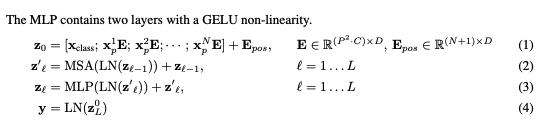

**Equeation 1**

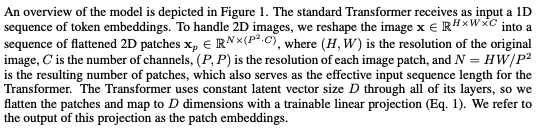

**Equation 1**

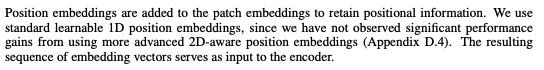




```python
x_input = [class_token, image_patch_1, image_patch_2, image_patch_3...] + [class_token_position, image_patch_1_position, image_patch_2_position, image_patch_3_position...]
```


**Equations 2 & 3**

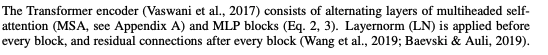


```python
# Equation 2
x_output_MSA_block = MSA_layer(LN_layer(x_input)) + x_input
```


```python
# Equation 3
x_output_MLP_block = MLP_layer(LN_layer(x_output_MSA_block)) + x_output_MSA_block
```



**Equation 4**

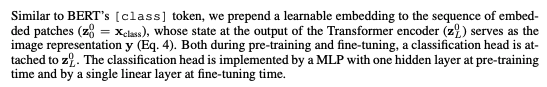

Note: MLP = Multi-Layer Perceptron = a neural network with at least 1 hidden layer.

```python
y = Linear_layer(LN_layer(x_output_MLP_block[0]))
```


### Table 1

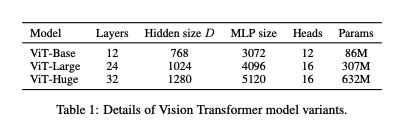


* ViT-Base, ViT-Large and ViT-Huge are all different sizes of the same architecture. The larger the model, the more parameters it has and the more data it needs to train effectively.
* layers - the number of transformer blocks in the model.
* Hidden size $D$ -  the embedding size of the model (the number of features in the input and output of each layer).
* MLP size - the number of neurons in the hidden layer of the MLP block.
* Heads - the number of attention heads in the multi-head self-attention (MSA) block.
* Parameters - the total number of trainable parameters in the model.










# 4. Equation 1: Split data into patches and creating the class, position and patch embedding

Layers = Input image -> Patch embedding -> Class embedding -> Position embedding (input -> function -> output)

What's the input shape?
* Input shape = (224,224,3) -> single image -> (height, width, color channels)

What is the output shape?
* Output shape = (num_patches + 1, embedding_dim) -> sequence of patch embeddings with class token


* Input shape: $H\times{W}\times{C}$ (height x width x color channels)
* Output shape: ${N\times\left(P^{2}\cdot{C}\right)}$

Where:
* H = height of the input image
* W = width of the input image
* C = color channels of the input image
* P = patch size (height and width of each patch)
* N = number of patches = (height * width) / p^2
* D = embedding dimension (the size of the vector representing each patch)



### 4.1 Calculating patch embedding input and output shapes by hand




In [29]:
# Create example values
height = 224 # H ("The training resolution is 224.")
width = 224 # W
color_channels = 3 # C
patch_size = 16 # P

# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [30]:
# Input shape (this is the size of a single image)
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


### 4.2 Turning a single image into patches


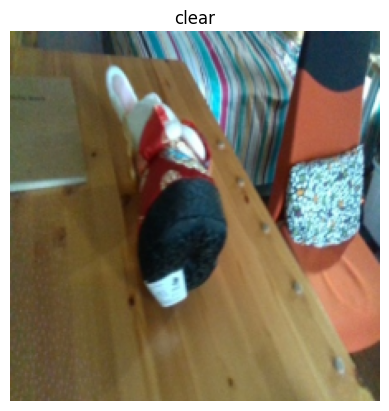

In [31]:
# View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

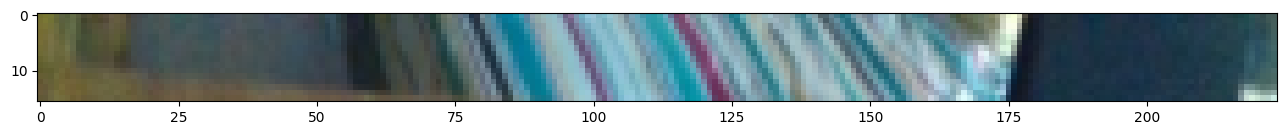

In [32]:
# Change image shape to be compatible with matplotlib (color_channels, height, width) -> (height, width, color_channels)
image_permuted = image.permute(1, 2, 0)

# Index to plot the top row of patched pixels
patch_size = 16
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :]);

In [ ]:
image.shape

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


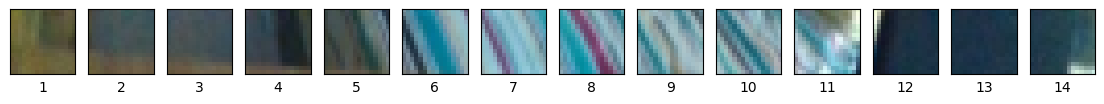

In [33]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size, # one column for each patch
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Iterate through number of patches in the top row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :]); # keep height index constant, alter the width index
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


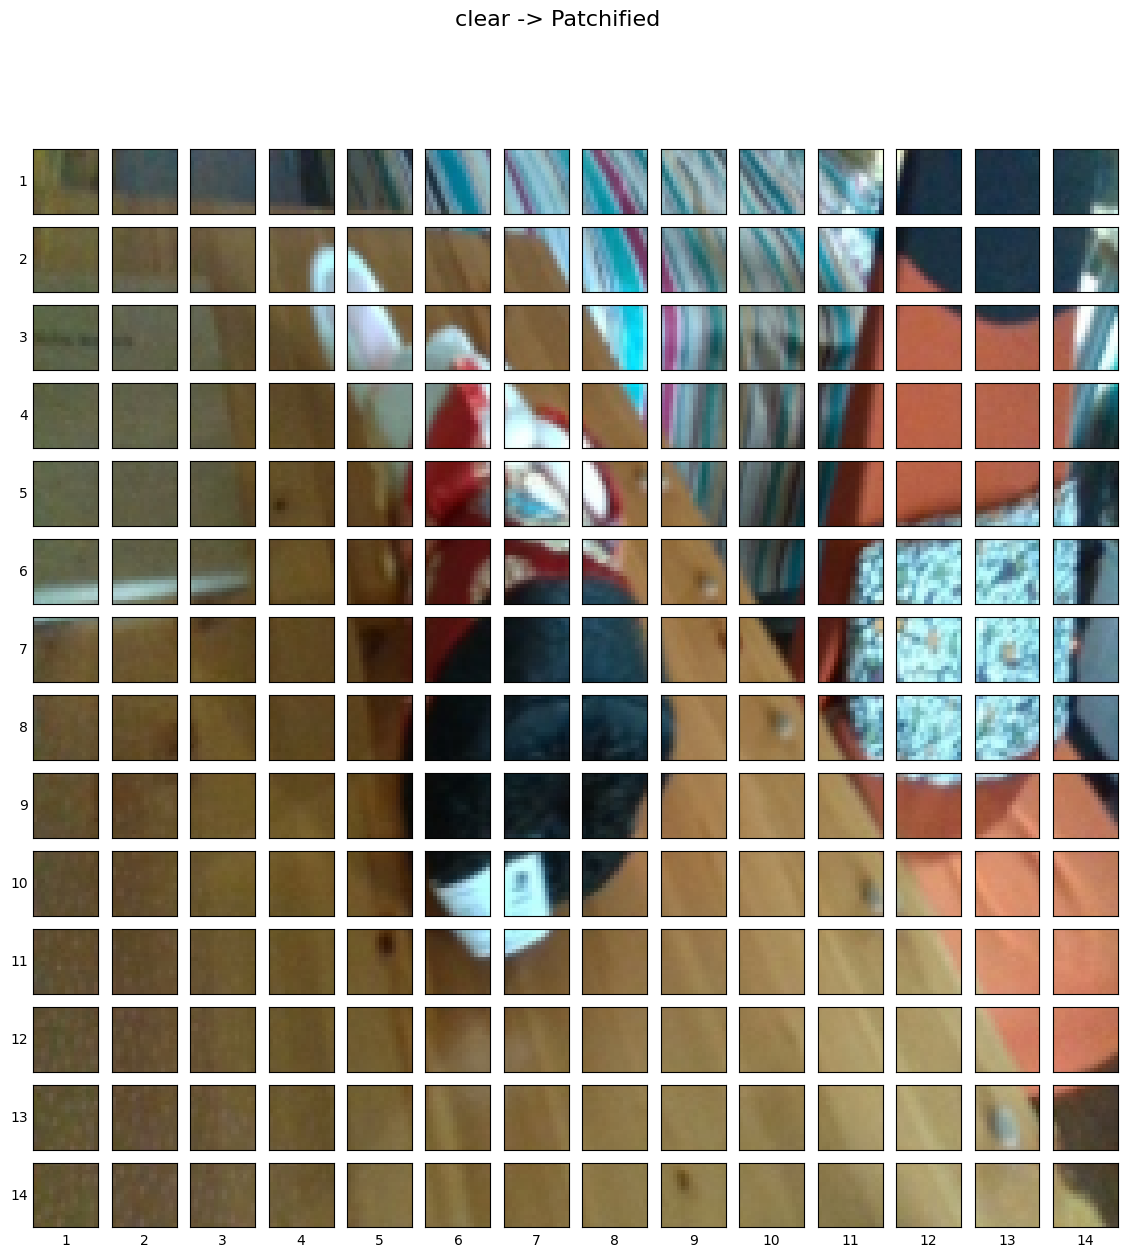

In [34]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

## 4.3 Creating image patches with `torch.nn.Conv2d()`
Perphaps we could creat the image patches and patch embedding in a single step using `torch.nn.Conv2d()` and setting the kernel size and stride parameters to `patch_size`. This would allow us to create the patches and embed them in a single step, rather than having to do it in two separate steps. 


In [42]:
# create conv2d layer to create patches and embed them in a single step
from torch import nn

#set the patch size
patch_size = 16

# Create a conv2d layer with hyperparameters to create patches and embed them in a single step

conv2d = nn.Conv2d(in_channels=3, # color channels
                   out_channels=768, # embedding dimension
                   kernel_size=patch_size, # patch size
                   stride=patch_size, # patch size
                   padding=0) 
conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

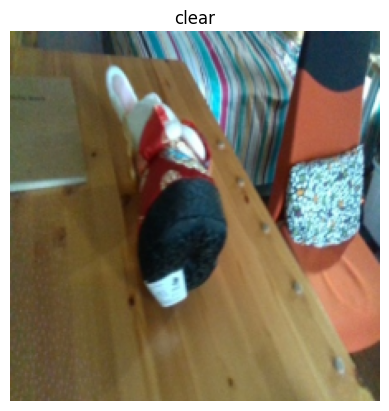

In [36]:
# View single image shape
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

In [44]:
# Pass the image through the convolutional layer.

image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension
print(image_out_of_conv.shape) # (batch_size, embedding_dimension, num_patches_height, num_patches_width)

torch.Size([1, 768, 14, 14])


Now we have passed a single image through the convolutional (`conv2d`) layer, let's check the output shape.

```python
torch.Size([1, 768, 14, 14]) # (batch_size, embedding_dimension, num_patches_height, num_patches_width)
```

In [45]:
image_out_of_conv.requires_grad

True

Showing random convolutional feature maps from indexes: [466, 443, 49, 303, 655]


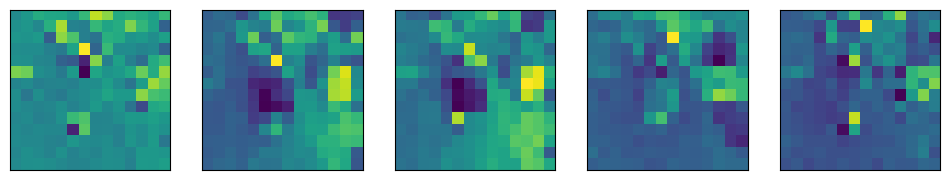

In [56]:
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 758), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [52]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[ 2.9166e-03, -4.3407e-02, -3.7849e-02, -5.3846e-02, -7.9755e-02,
           -2.7462e-01, -2.5210e-01, -2.7383e-01, -2.1910e-01, -2.3130e-01,
           -9.0645e-02, -7.3057e-02, -1.0863e-01,  1.6383e-03],
          [-1.2520e-03,  1.1151e-02, -2.0520e-02, -7.0056e-02, -2.3601e-02,
            4.4650e-02,  5.6047e-02, -3.6083e-01, -1.6128e-01, -1.1939e-01,
           -1.7881e-01,  8.2113e-02, -1.0984e-01,  1.3570e-01],
          [-3.0910e-02, -6.1384e-02, -3.0273e-02,  5.2604e-02, -3.0658e-01,
           -1.2106e-01,  2.6084e-02, -2.0367e-01, -1.4443e-01, -9.9402e-02,
           -1.7302e-01,  1.1800e-01,  9.0551e-02, -1.0627e-01],
          [-3.3294e-02, -3.7078e-02, -3.5047e-02,  3.2277e-02, -8.5511e-03,
           -2.4471e-02, -1.1067e-01,  1.1403e-01, -2.1146e-01, -1.1407e-01,
           -1.7070e-01,  1.3072e-01,  1.2268e-01, -2.2977e-02],
          [-3.4207e-02, -2.1975e-02, -2.6231e-02,  4.6556e-02,  6.2577e-02,
            1.3278e-01, -1.0353e-01, -1.0375e-01, -3.3990e-0

### 4.4 Flattening the patch embeddings with `torch.flatten()`
Right now there are a series of convolutional feature maps (patch embeddings) that I want to flatten into a sequence of patch embedding to satisfy the input criteria of the ViT Transformer Encoder.


In [57]:
# Current tensor shape
print(f"Current tensor shape: {image_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width]")

Current tensor shape: torch.Size([1, 768, 14, 14]) -> [batch, embedding_dim, feature_map_height, feature_map_width]


Want : (batch_size, num_patches, embedding_dimension) = (1, 196, 768)

In [61]:
# Create flatten layer
flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3) # flatten feature_map_width (dimension 3)
flatten(image_out_of_conv).shape

torch.Size([1, 768, 196])

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


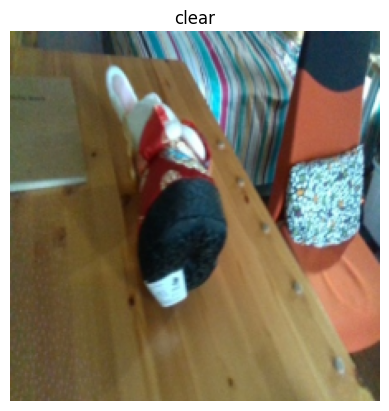

In [62]:
# 1. View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

# 2. Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

# 3. Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [64]:
# Rearrange the flattened image feature map to have the shape (batch_size, num_patches, embedding_dimension)
image_out_of_conv_flattened.permute(0, 2, 1).shape

torch.Size([1, 196, 768])